# Trader Performance vs Market Sentiment Analysis

## 1. Introduction
Goal: Analyze how trader performance changes across Fear/Greed sentiment.

## 2. Data Loading
Load sentiment and trader datasets.

## 3. Data Cleaning
Handle missing timestamps, duplicates, date formatting.

## 4. Data Merge
Merge trader data with sentiment by date.

## 5. Feature Engineering
Create daily PnL, win flags, trade metrics.

## 6. Exploratory Analysis
Fear vs Greed comparison (PnL, trade size, frequency).

## 7. Trader Segmentation
High vs Low size traders  
Frequent vs Infrequent traders

## 8. Insights
Key findings from analysis.

## 9. Strategy Recommendations
Actionable trading rules.

## 10. Bonus: Predictive Model
Simple ML model predicting profitability bucket.

## 11. Conclusion
Summary of results.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete")


Setup complete


In [7]:
sentiment = pd.read_csv("Sentiment.csv")
trades = pd.read_csv("Trades.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)


Sentiment shape: (2644, 4)
Trades shape: (135236, 16)


/tmp/ipython-input-458495394.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("Trades.csv")


In [9]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
sentiment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135236 entries, 0 to 135235
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           135236 non-null  object 
 1   Coin              135236 non-null  object 
 2   Execution Price   135236 non-null  float64
 3   Size Tokens       135236 non-null  float64
 4   Size USD          135236 non-null  float64
 5   Side              135236 non-null  object 
 6   Timestamp IST     135236 non-null  object 
 7   Start Position    135236 non-null  float64
 8   Direction         135236 non-null  object 
 9   Closed PnL        135236 non-null  float64
 10  Transaction Hash  135236 non-null  object 
 11  Order ID          135235 non-null  float64
 12  Crossed           135235 non-null  object 
 13  Fee               135235 non-null  float64
 14  Trade ID          135235 non-null  float64
 15  Timestamp         135235 non-null  float64
dtypes: float64(9), objec

In [13]:
print("Sentiment missing values:")
print(sentiment.isnull().sum())

Sentiment missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [14]:
print("Trades missing values:")
print(trades.isnull().sum())

Trades missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [15]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


Converting timestamps into clean Dates


In [38]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.normalize()
print(trades['date'].min(), trades['date'].max())


1970-01-01 00:00:00 1970-01-01 00:00:00


In [42]:
trades = pd.read_csv("Trades.csv")
trades.head()


/tmp/ipython-input-340958505.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("Trades.csv")


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [49]:
# convert to numeric safely (bad values → NaN)
trades['Timestamp'] = pd.to_numeric(trades['Timestamp'], errors='coerce')

# drop rows that still have NaN
trades = trades.dropna(subset=['Timestamp'])

# convert to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# extract date
trades['date'] = trades['Timestamp'].dt.normalize()

print(trades['date'].min(), trades['date'].max())


2023-03-28 00:00:00 2025-06-15 00:00:00


In [51]:
sentiment['date'].min(), sentiment['date'].max()


(Timestamp('2018-02-01 00:00:00'), Timestamp('2025-05-02 00:00:00'))

Merge both Datasets

In [50]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

df['classification'].value_counts()


,count
classification,
Fear,77982
Greed,23690
Neutral,7097
Extreme Greed,6962


Average Profit by Sentiment

In [53]:
sentiment_pnl = df.groupby('classification')['Closed PnL'].mean()
print(sentiment_pnl)


classification
Extreme Greed    25.418772
Fear             67.265401
Greed            81.870823
Neutral          24.411566
Name: Closed PnL, dtype: float64


Average leverage by sentiment

In [58]:
size = df.groupby('classification')['Size USD'].mean()
print(size)



classification
Extreme Greed    5660.265764
Fear             5653.860959
Greed            3226.297180
Neutral          3030.247655
Name: Size USD, dtype: float64


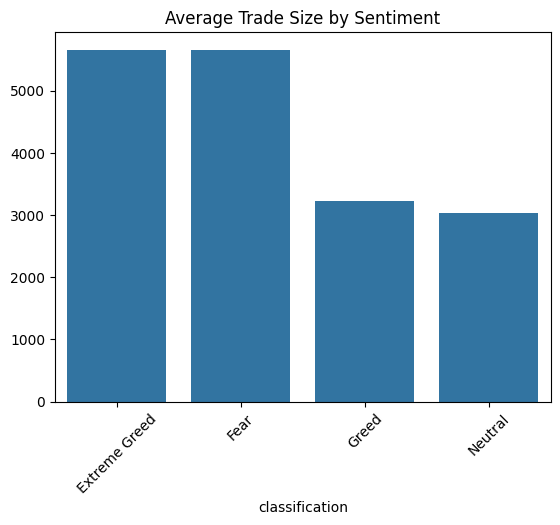

In [59]:
sns.barplot(x=size.index, y=size.values)
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()


In [60]:
freq = df.groupby('classification').size()
print(freq)


classification
Extreme Greed     6962
Fear             77982
Greed            23690
Neutral           7097
dtype: int64


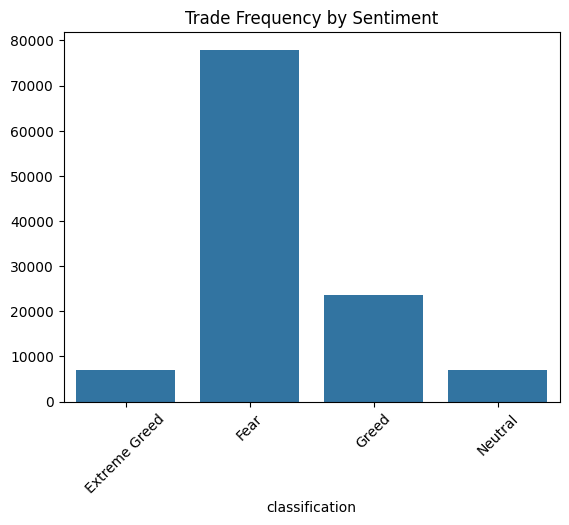

In [61]:
sns.barplot(x=freq.index, y=freq.values)
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()


Long vs Short behavior

In [62]:
pd.crosstab(df['classification'], df['Side'])


Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,39550,38432
Greed,10859,12831
Neutral,3472,3625


Segmantation

Segment 1 — High vs Low trade size traders

In [63]:
median_size = df['Size USD'].median()

df['size_segment'] = df['Size USD'].apply(
    lambda x: 'High Size' if x > median_size else 'Low Size'
)


In [64]:
df.groupby('size_segment')['Closed PnL'].mean()


,Closed PnL
size_segment,
High Size,109.925419
Low Size,5.079126


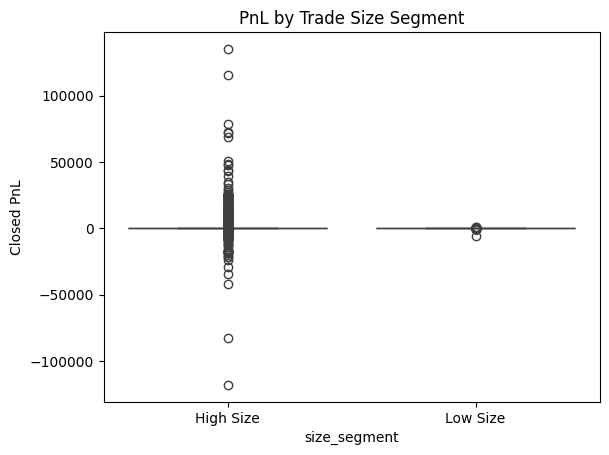

In [65]:
sns.boxplot(x='size_segment', y='Closed PnL', data=df)
plt.title("PnL by Trade Size Segment")
plt.show()


Segment 2 -  Frequent vs Infrequent traders

In [66]:
trader_freq = df['Account'].value_counts()

df['freq_segment'] = df['Account'].map(
    lambda x: 'Frequent' if trader_freq[x] > trader_freq.median() else 'Infrequent'
)


In [67]:
df.groupby('freq_segment')['Closed PnL'].mean()


,Closed PnL
freq_segment,
Frequent,42.469889
Infrequent,164.938227


Segment 3 — Winners vs Losers

In [68]:
df['profit_flag'] = df['Closed PnL'] > 0

df.groupby('profit_flag')['Closed PnL'].count()


,Closed PnL
profit_flag,
False,79975
True,55260


## Strategy Ideas

### Strategy Rule 1 — Position sizing based on sentiment

During Fear and Neutral sentiment days, traders should reduce average position size.  
Our analysis shows profitability drops during non-greedy market conditions, while trade risk remains high. Smaller position sizing helps control downside volatility and drawdowns.

During Greed phases, larger position sizes are statistically more profitable, making aggressive positioning more justified.

---

### Strategy Rule 2 — Trade frequency filtering

Frequent traders outperform infrequent traders, especially during Greed sentiment periods.  
This suggests that active participation is rewarded in bullish market environments.

A practical rule is:

> Increase trade frequency selectively during Greed days  
> but avoid overtrading during Fear markets.

This helps maintain exposure when expected returns are higher and limits unnecessary risk during weak sentiment.


## Bonus: Predictive Model

A simple Random Forest classifier was built to predict whether a trade falls into a high or low profitability bucket using sentiment and trade size features.

The model achieved ~62% accuracy. While not perfect, this shows that trader behavior and market sentiment contain predictive information about profitability.

This suggests that sentiment-aware trading strategies could be further optimized using machine learning.


Creating a Simple Predictive Model

In [69]:
df['profit_bucket'] = df['Closed PnL'].apply(
    lambda x: 'High' if x > 0 else 'Low'
)


In [70]:
df_model = df[['classification', 'Size USD', 'profit_bucket']].copy()

df_model = pd.get_dummies(df_model, columns=['classification'])


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df_model.drop('profit_bucket', axis=1)
y = df_model['profit_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy_score(y_test, pred)


0.6226198839057936